In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
import matplotlib
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(1.5)) )

## Figure 4a

In [4]:
### For Figure 5 neural subcluster merging highly variable + subcluster specific motifs
with open("/media/gary/Chew/figures/neural_subcluster/Mlig_neuralsubcluster.pkl", "rb") as f:
    Mlig_dict = pickle.load(f)
    
with open("/media/gary/Chew/figures/neural_subcluster/Smed_neuralsubcluster.pkl", "rb") as f:
    Smed_dict = pickle.load(f)
    
with open("/media/gary/Chew/figures/neural_subcluster/Sman_neuralsubcluster.pkl", "rb") as f:
    Sman_dict = pickle.load(f)

In [5]:
Mlig_neural_subcluster = pd.read_csv("../Mlig.neural_subcluster_markers_20250806.csv",index_col=0)
Smed_neural_subcluster = pd.read_csv("../Smed.neural_subcluster_markers_20250806.csv",index_col=0)
Sman_neural_subcluster = pd.read_csv("../Sman.neural_subcluster_markers_20250806.csv",index_col=0)
Mlig_highly_variable = Mlig_neural_subcluster.columns[Mlig_neural_subcluster.any(axis=0)].tolist()
Smed_highly_variable = Smed_neural_subcluster.columns[Smed_neural_subcluster.any(axis=0)].tolist()
Sman_highly_variable = Sman_neural_subcluster.columns[Sman_neural_subcluster.any(axis=0)].tolist()

highly_variable_shared = set(Mlig_highly_variable) & set(Smed_highly_variable) & set(Sman_highly_variable)

In [6]:
Mlig_neural_subcluster = Mlig_neural_subcluster[Mlig_neural_subcluster.columns[Mlig_neural_subcluster.columns.isin(highly_variable_shared)]]
Mlig_neural_subcluster.index = [f"M{i}" for i in Mlig_neural_subcluster.index]
Smed_neural_subcluster = Smed_neural_subcluster[Smed_neural_subcluster.columns[Smed_neural_subcluster.columns.isin(highly_variable_shared)]]
Smed_neural_subcluster.index = [f"P{i}" for i in Smed_neural_subcluster.index]
Sman_neural_subcluster = Sman_neural_subcluster[Sman_neural_subcluster.columns[Sman_neural_subcluster.columns.isin(highly_variable_shared)]]
Sman_neural_subcluster.index = [f"S{i}" for i in Sman_neural_subcluster.index]

In [8]:
import numpy as np
import pandas as pd

# subcluster order
Mlig_subcluster = ['M0','M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11']
Smed_subcluster = ['P0','P1','P2','P3','P4','P5','P6','P7','P8']
Sman_subcluster = ['S0','S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12','S13','S14','S15','S16','S17']

# make sure rows are in the desired order
Mlig_mat = Mlig_neural_subcluster.loc[Mlig_subcluster]
Smed_mat = Smed_neural_subcluster.loc[Smed_subcluster]
Sman_mat = Sman_neural_subcluster.loc[Sman_subcluster]

# convert each row to a set of motifs with True / 1 values
Mlig_sets = {
    idx: set(Mlig_mat.columns[Mlig_mat.loc[idx].astype(bool)])
    for idx in Mlig_mat.index
}

Smed_sets = {
    idx: set(Smed_mat.columns[Smed_mat.loc[idx].astype(bool)])
    for idx in Smed_mat.index
}

Sman_sets = {
    idx: set(Sman_mat.columns[Sman_mat.loc[idx].astype(bool)])
    for idx in Sman_mat.index
}

# reusable function
def compute_jaccard_df(dict1, dict2, rows, cols):
    arr = np.zeros((len(rows), len(cols)))
    
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            inter = len(dict1[r] & dict2[c])
            union = len(dict1[r] | dict2[c])
            arr[i, j] = inter / union if union > 0 else np.nan
            
    return pd.DataFrame(arr, index=rows, columns=cols)

# pairwise jaccard dataframes
jaccard_Mlig_Smed_df = compute_jaccard_df(Mlig_sets, Smed_sets, Mlig_subcluster, Smed_subcluster)
jaccard_Mlig_Sman_df = compute_jaccard_df(Mlig_sets, Sman_sets, Mlig_subcluster, Sman_subcluster)
jaccard_Smed_Sman_df = compute_jaccard_df(Smed_sets, Sman_sets, Smed_subcluster, Sman_subcluster)

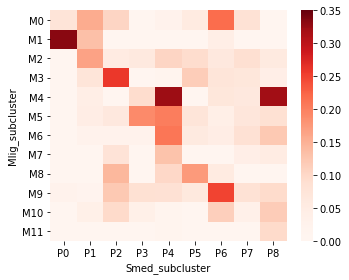

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Mlig_Smed_df, cmap=custom_cmap, fmt=".3f", ax=ax,vmax=0.35)
ax.set_xlabel("Smed_subcluster")
ax.set_ylabel("Mlig_subcluster")
plt.tight_layout()
plt.show()

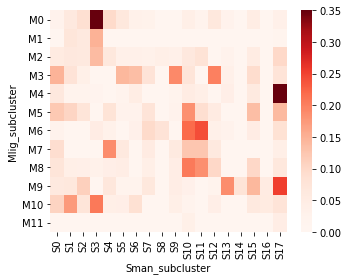

In [91]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Mlig_Sman_df, cmap=custom_cmap, fmt=".3f", ax=ax,vmax=0.35)
ax.set_xlabel("Sman_subcluster")
ax.set_ylabel("Mlig_subcluster")
plt.tight_layout()
plt.show()

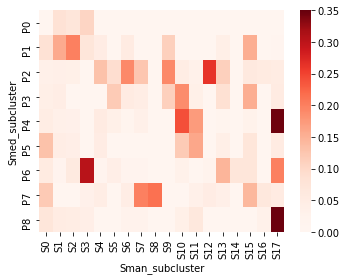

In [92]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Smed_Sman_df, cmap=custom_cmap, fmt=".3f", ax=ax,vmax=0.35)
ax.set_xlabel("Sman_subcluster")
ax.set_ylabel("Smed_subcluster")
plt.tight_layout()
plt.show()